# 📊 End-to-End Sales Forecasting & Demand Intelligence System

### Internship Project – Week 3 & Week 4

**Name:** Srimithula

**Project:** Sales Forecasting & Demand Intelligence System

**Objective:**
Build an intelligent sales forecasting system that predicts future product demand, detects anomalies, segments products based on demand patterns, and presents the results through an interactive dashboard.

# Task 1: Data Loading, Merging & Deep Exploration

In this task, we will:

- Load the Superstore Sales dataset
- Explore the dataset structure
- Check for missing values and duplicates
- Convert date columns
- Create new time-based features
- Aggregate sales into weekly and monthly data
- Perform exploratory data analysis (EDA)

In [64]:
# ===============================
# Import Required Libraries
# ===============================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

In [65]:
## Loading the Dataset
from google.colab import files

df = pd.read_csv("/content/sample_data/train.csv")

In [66]:
## Initial Data Exploration

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [67]:
#Information of the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [68]:
df.shape

(9800, 18)

In [69]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [70]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [71]:
df.duplicated().sum()

np.int64(0)

## Converting Date Columns

In [72]:
df[['Order Date', 'Ship Date']].head()

,Order Date,Ship Date
0,08/11/2017,11/11/2017
1,08/11/2017,11/11/2017
2,12/06/2017,16/06/2017
3,11/10/2016,18/10/2016
4,11/10/2016,18/10/2016


In [73]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')

## Creating Time-Based Features

In [74]:
# Create time-based features
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.month_name()
df['Week Number'] = df['Order Date'].dt.isocalendar().week
df['Day of Week'] = df['Order Date'].dt.day_name()
df['Quarter'] = df['Order Date'].dt.quarter

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df['Season'] = df['Month'].apply(get_season)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Year,Month,Month Name,Week Number,Day of Week,Quarter,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,45,Wednesday,4,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,45,Wednesday,4,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,24,Monday,2,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,41,Tuesday,4,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,41,Tuesday,4,Autumn


## Aggregating Weekly and Monthly Sales

To analyze sales trends over time, we aggregate the sales data into weekly and monthly totals. These aggregated datasets will be used for time series analysis and forecasting in later tasks.

In [75]:
# Aggregate Weekly and Monthly Sales

df.set_index('Order Date', inplace=True)

weekly_sales = df['Sales'].resample('W').sum()
monthly_sales = df['Sales'].resample('M').sum()

print("Weekly Sales")
print(weekly_sales.head())

print("\nMonthly Sales")
print(monthly_sales.head())

print("\nWeekly Shape:", weekly_sales.shape)
print("Monthly Shape:", monthly_sales.shape)

Weekly Sales
Order Date
2015-01-04     304.508
2015-01-11    4619.108
2015-01-18    4130.533
2015-01-25    3092.544
2015-02-01    2527.914
Freq: W-SUN, Name: Sales, dtype: float64

Monthly Sales
Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64

Weekly Shape: (209,)
Monthly Shape: (48,)


## Business Question 1: Which Product Category Generates the Highest Total Revenue?

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


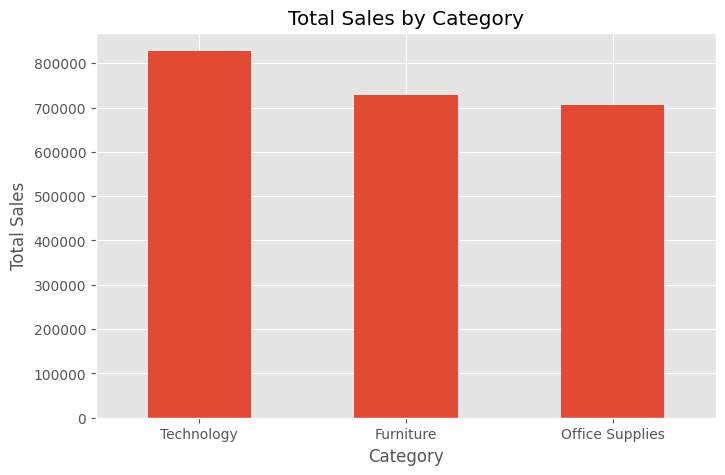

In [76]:
# Total sales by category
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

print(category_sales)

# Visualization
plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)

plt.show()

### Observation

- The **Technology** category generated the highest total revenue, with total sales of approximately **827,456**.
- **Furniture** ranked second with around **728,659** in sales.
- **Office Supplies** generated the lowest revenue among the three categories, with approximately **705,422** in sales.
- This indicates that Technology products contribute the most to the company's overall revenue and should be a key focus for inventory planning and future sales forecasting.

## Business Question 2: Which Region Has the Most Consistent Sales Growth Over 4 Years?

Region      Central        East        South         West
Year                                                     
2015    102920.5206  127652.819  103374.9055  145907.9630
2016    102425.1724  153225.183   70076.0825  133709.5675
2017    145673.8800  178511.538   93535.9035  182471.2285
2018    141627.3402  210129.186  122164.5675  248130.9255


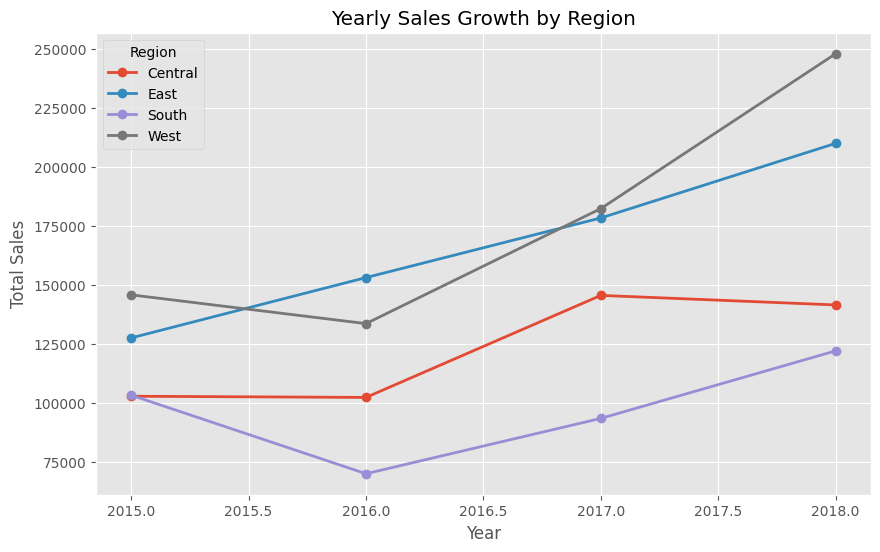

In [77]:
# Yearly sales by region
region_yearly_sales = df.groupby(['Year', 'Region'])['Sales'].sum().unstack()

print(region_yearly_sales)

# Plot
plt.figure(figsize=(10,6))

for region in region_yearly_sales.columns:
    plt.plot(region_yearly_sales.index,
             region_yearly_sales[region],
             marker='o',
             linewidth=2,
             label=region)

plt.title("Yearly Sales Growth by Region")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.legend(title="Region")
plt.grid(True)

plt.show()

### Observation

- The **West** region showed the strongest overall sales growth over the four-year period, with sales increasing significantly from 2016 to 2018.
- The **East** region also demonstrated steady and consistent growth each year.
- The **Central** and **South** regions experienced fluctuations in sales, making their growth less consistent.
- Overall, the **East region** exhibited the most consistent year-over-year growth, while the **West region** achieved the highest overall sales growth by the end of 2018.

## Business Question 3: What is the Average Time Between Order Date and Ship Date? Does It Vary by Region?

Average Shipping Time: 3.96 days

Average Shipping Time by Region
Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Shipping Days, dtype: float64


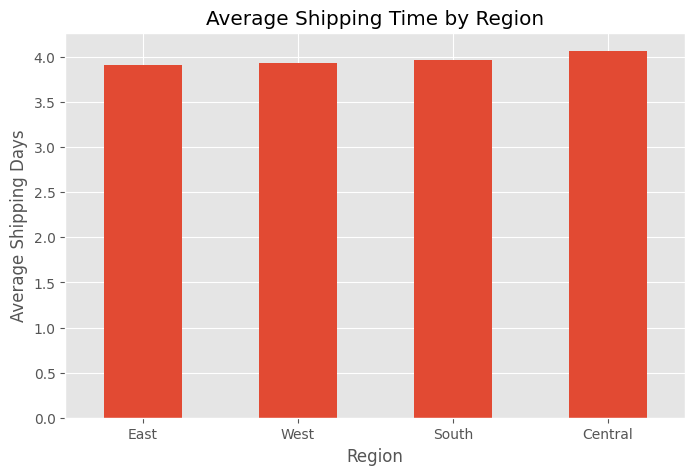

In [78]:
# Calculate shipping time
df['Shipping Days'] = (df['Ship Date'] - df.index).dt.days

# Average shipping time
avg_shipping = df['Shipping Days'].mean()
print(f"Average Shipping Time: {avg_shipping:.2f} days")

# Shipping time by region
shipping_region = df.groupby('Region')['Shipping Days'].mean().sort_values()

print("\nAverage Shipping Time by Region")
print(shipping_region)

# Plot
plt.figure(figsize=(8,5))
shipping_region.plot(kind='bar')

plt.title("Average Shipping Time by Region")
plt.xlabel("Region")
plt.ylabel("Average Shipping Days")
plt.xticks(rotation=0)

plt.show()

### Observation

- The average time between **Order Date** and **Ship Date** is **3.96 days**.
- The **East** region has the shortest average shipping time (**3.91 days**), while the **Central** region has the longest (**4.07 days**).
- The difference in average shipping time across regions is very small, indicating that the company's shipping process is generally consistent and efficient across all regions.

## Business Question 4: Are There Months That Consistently Spike Across All Years (Seasonality)?

Month Name     January    February       March       April         May  \
Year                                                                     
2015        14205.7070   4519.8920  55205.7970  27906.8550  23644.3030   
2016        18066.9576  11951.4110  32339.3184  34154.4685  29959.5305   
2017        18542.4910  22978.8150  51165.0590  38679.7670  56656.9080   
2018        43476.4740  19920.9974  58863.4128  35541.9101  43825.9822   

Month Name        June       July      August   September     October  \
Year                                                                    
2015        34322.9356  33781.543  27117.5365  81623.5268  31453.3930   
2016        23599.3740  28608.259  36818.3422  63133.6060  31011.7375   
2017        39724.4860  38320.783  30542.2003  69193.3909  59583.0330   
2018        48190.7277  44825.104  62837.8480  86152.8880  77448.1312   

Month Name     November    December  
Year                                 
2015         77907.6607  68167.0585  
20

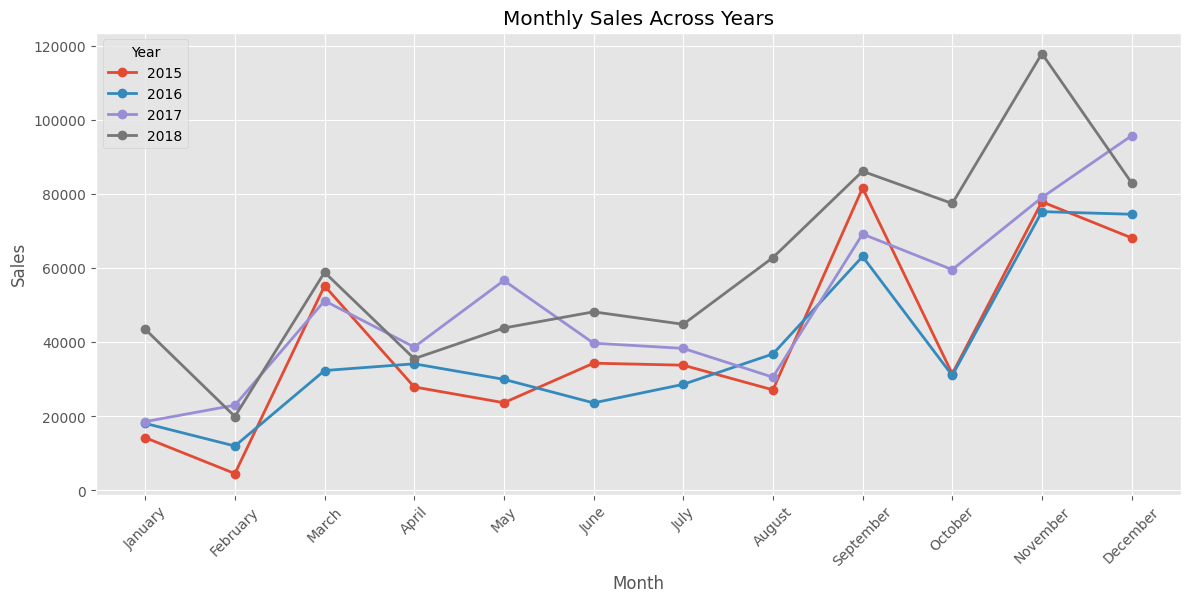

In [79]:
monthly_year_sales = df.groupby(['Year','Month Name'])['Sales'].sum().unstack()

# Arrange months correctly
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

monthly_year_sales = monthly_year_sales[month_order]

print(monthly_year_sales)

plt.figure(figsize=(14,6))

for year in monthly_year_sales.index:
    plt.plot(month_order,
             monthly_year_sales.loc[year],
             marker='o',
             linewidth=2,
             label=year)

plt.title("Monthly Sales Across Years")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.legend(title="Year")

plt.show()

### Observation

- The monthly sales trend shows a clear seasonal pattern across all four years.
- Sales generally increase during the second half of the year, with the highest sales occurring in **November** and **December**.
- Sales are comparatively lower during the early months of the year, particularly **January** and **February**.
- The recurring increase in sales during the year-end indicates strong seasonal demand, suggesting that inventory planning should be strengthened before the holiday season.


# Task 2: Time Series Analysis & Decomposition

In this task, we analyze the monthly sales trend over time, decompose the time series into its trend, seasonal, and residual components, and determine whether the series is stationary using the Augmented Dickey-Fuller (ADF) test.




## Overall Monthly Sales Trend

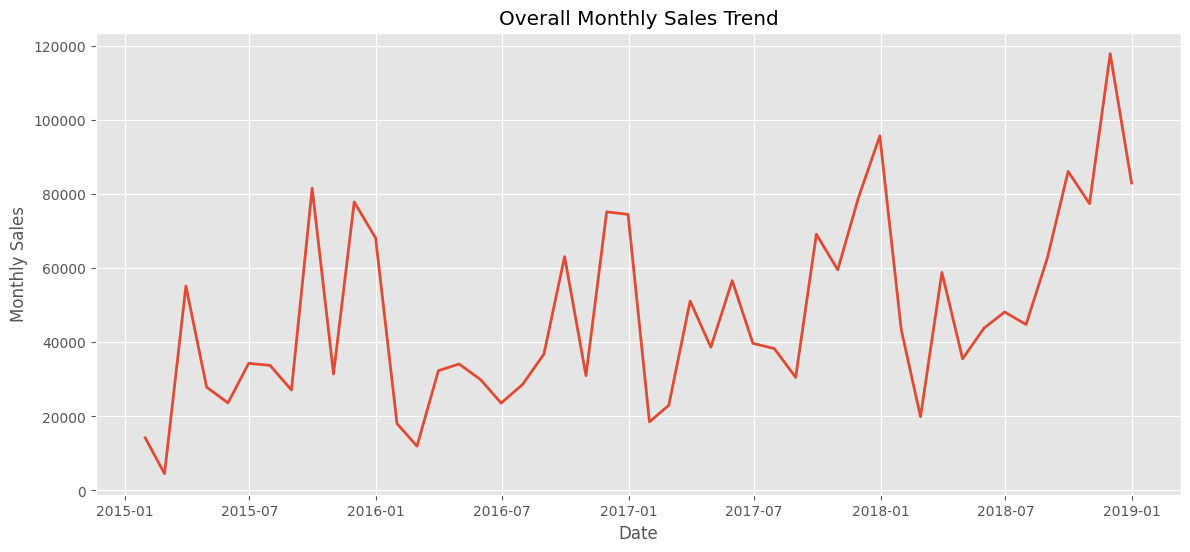

In [80]:
# Plot Monthly Sales Trend

plt.figure(figsize=(14,6))

plt.plot(monthly_sales.index,
         monthly_sales.values,
         linewidth=2)

plt.title("Overall Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Monthly Sales")
plt.grid(True)

plt.show()

### Observation

- The monthly sales trend shows noticeable fluctuations throughout the four-year period.
- Despite short-term ups and downs, the overall sales trend gradually increases over time, indicating business growth.
- Higher sales peaks are observed during the later years, particularly in 2018.
- The increasing trend suggests a positive growth pattern in overall sales performance.

## Time Series Decomposition

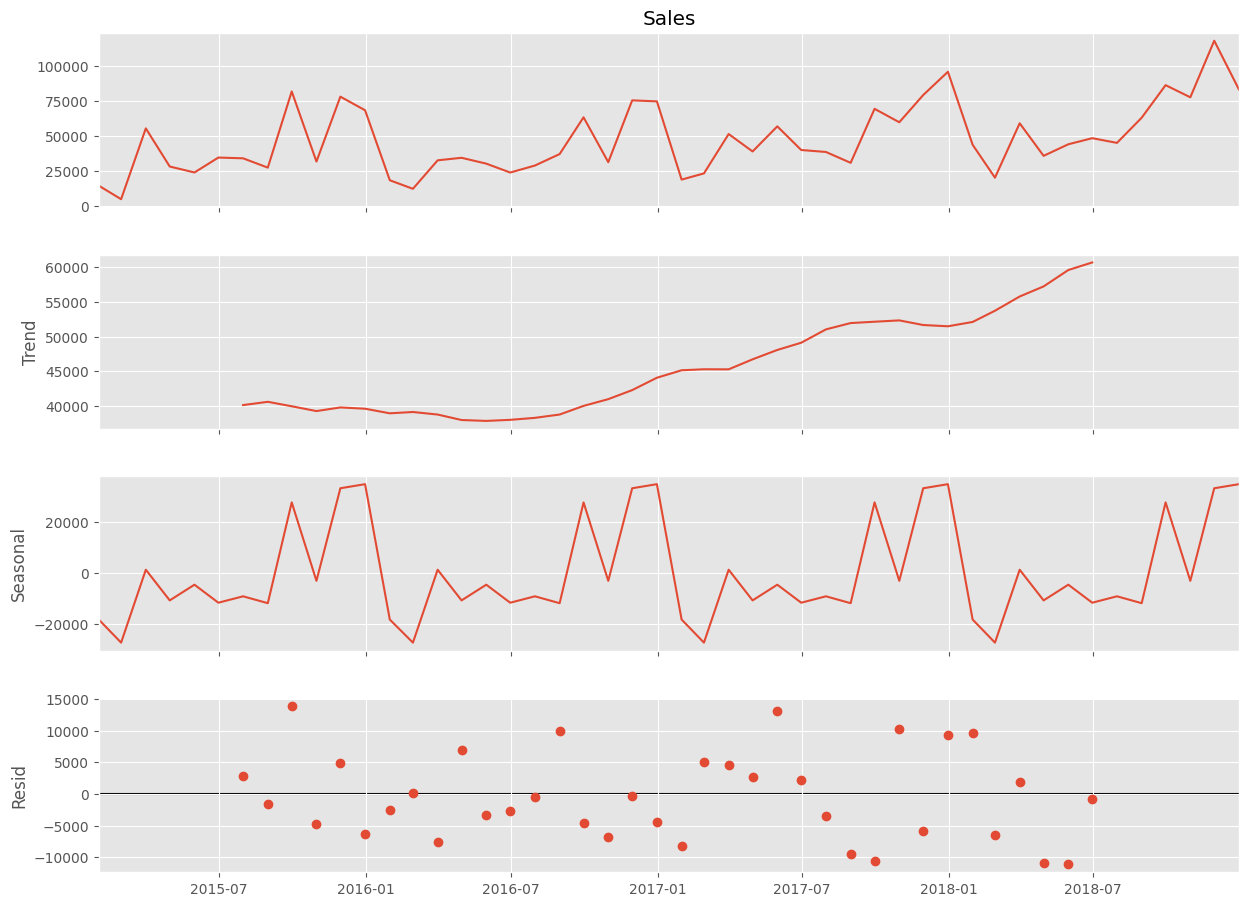

In [81]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    monthly_sales,
    model='additive',
    period=12
)

fig = decomposition.plot()
fig.set_size_inches(14,10)

plt.show()

### Observation

- The trend component indicates a gradual increase in sales over time, showing sustained business growth.
- The seasonal component reveals recurring monthly patterns, indicating that sales are influenced by seasonal demand.
- The residual component contains random fluctuations that are not explained by the trend or seasonality.
- Overall, the decomposition confirms that the sales data contains both an upward trend and seasonal variations, making it suitable for time series forecasting.

## Augmented Dickey-Fuller (ADF) Test

In [82]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(monthly_sales)

print("ADF Statistic :", adf_result[0])
print("p-value :", adf_result[1])

print("\nCritical Values")

for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic : -4.416136761430769
p-value : 0.00027791039276670623

Critical Values
1%: -3.5778480370438146
5%: -2.925338105429433
10%: -2.6007735310095064


### Observation

- The Augmented Dickey-Fuller (ADF) test produced a p-value of **0.000278**, which is less than the significance level of **0.05**.
- Therefore, the null hypothesis of non-stationarity is rejected.
- This indicates that the monthly sales series is **stationary** and suitable for forecasting models that require stationarity, such as SARIMA.

### What is Stationarity?

A time series is said to be **stationary** if its statistical properties, such as mean and variance, remain constant over time. Stationarity is an important assumption for many forecasting models like SARIMA. The Augmented Dickey-Fuller (ADF) test is used to determine whether a time series is stationary.

## Applying First-Order Differencing

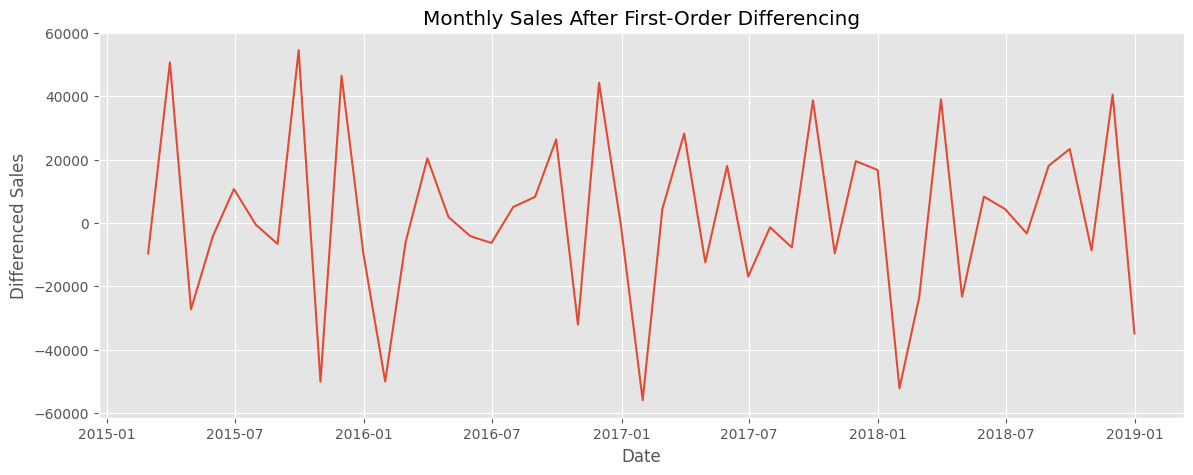

In [83]:
monthly_sales_diff = monthly_sales.diff().dropna()

plt.figure(figsize=(14,5))

plt.plot(monthly_sales_diff)

plt.title("Monthly Sales After First-Order Differencing")
plt.xlabel("Date")
plt.ylabel("Differenced Sales")

plt.grid(True)

plt.show()

### Observation

- First-order differencing was applied to illustrate the process of transforming a time series.
- The differenced series fluctuates around a relatively constant mean with reduced trend effects.
- Since the original series was already stationary according to the ADF test, differencing was not strictly required but is included for demonstration and comparison.

# Task 3: Sales Forecasting Using Three Different Models

In this task, three different forecasting techniques are implemented and compared:

- SARIMA (Statistical Forecasting)
- Facebook Prophet (Industry Forecasting Model)
- XGBoost Regressor (Machine Learning Model)

The models are evaluated using MAE, RMSE, and MAPE to determine the most suitable forecasting model for future sales prediction.

## Model 1: Seasonal AutoRegressive Integrated Moving Average (SARIMA)

SARIMA is a statistical forecasting model that captures trend, seasonality, and autocorrelation in time series data. It is widely used for forecasting seasonal business data.

In [84]:
#import the library

from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import numpy as np

In [85]:
#Split Train & Test

train = monthly_sales[:-3]
test = monthly_sales[-3:]

print("Training Size:", len(train))
print("Testing Size:", len(test))

Training Size: 45
Testing Size: 3


In [86]:
#Build SARIMA Model

sarima_model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_fit = sarima_model.fit()

print(sarima_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -347.979
Date:                            Sun, 12 Jul 2026   AIC                            705.958
Time:                                    05:06:26   BIC                            713.287
Sample:                                01-31-2015   HQIC                           708.387
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5680      0.242      2.347      0.019       0.094       1.042
ma.L1         -0.8985      0.177   

### Parameter Selection

The SARIMA model was configured with **order = (1,1,1)** and **seasonal order = (1,1,1,12)**.

- p = 1 : one autoregressive term
- d = 1 : first-order differencing
- q = 1 : one moving average term
- P = 1 : one seasonal autoregressive term
- D = 1 : one seasonal differencing
- Q = 1 : one seasonal moving average term
- m = 12 : yearly seasonality (12 months)

These parameters provide a reasonable baseline for monthly sales forecasting.

In [87]:
#Forecast Next 3 Months

forecast = sarima_fit.get_forecast(steps=3)

forecast_values = forecast.predicted_mean

confidence = forecast.conf_int()

print(forecast_values)

2018-10-31    66177.602425
2018-11-30    92049.249682
2018-12-31    99965.168723
Freq: ME, Name: predicted_mean, dtype: float64


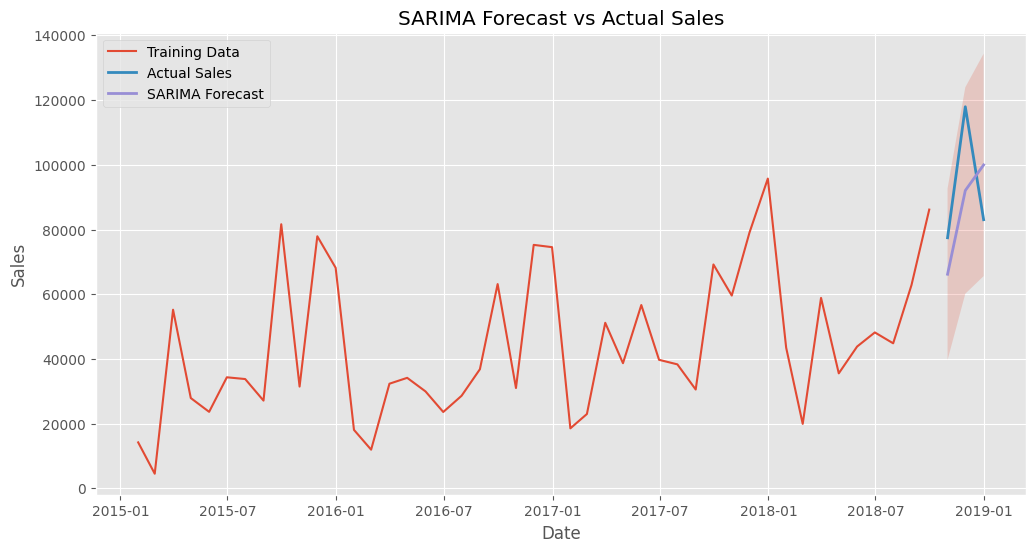

In [88]:
#plot

plt.figure(figsize=(12,6))

plt.plot(train.index, train, label="Training Data")

plt.plot(test.index, test, label="Actual Sales", linewidth=2)

plt.plot(test.index,
         forecast_values,
         label="SARIMA Forecast",
         linewidth=2)

plt.fill_between(
    confidence.index,
    confidence.iloc[:,0],
    confidence.iloc[:,1],
    alpha=0.2
)

plt.title("SARIMA Forecast vs Actual Sales")

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.show()

In [89]:
#Evaluation

mae = mean_absolute_error(test, forecast_values)

rmse = np.sqrt(mean_squared_error(test, forecast_values))

mape = np.mean(np.abs((test - forecast_values)/test))*100

print("MAE :", mae)
print("RMSE :", rmse)
print("MAPE :", mape)

MAE : 18031.40467222437
RMSE : 19009.18206635205
MAPE : 18.966498068433015


## Future Sales Forecast (Next 3 Months)

After evaluating the SARIMA model, it is retrained using the complete monthly sales dataset to forecast sales for the next three months. This provides an estimate of future demand along with confidence intervals.

In [90]:
# Retrain SARIMA on the complete dataset

final_sarima = SARIMAX(
    monthly_sales,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

final_sarima_fit = final_sarima.fit()

# Forecast next 3 months
future_forecast = final_sarima_fit.get_forecast(steps=3)

future_values = future_forecast.predicted_mean
future_conf = future_forecast.conf_int()

print("Future Sales Forecast")

display(future_values)

Future Sales Forecast


,predicted_mean
2019-01-31,43492.278984
2019-02-28,34805.105254
2019-03-31,69907.412190


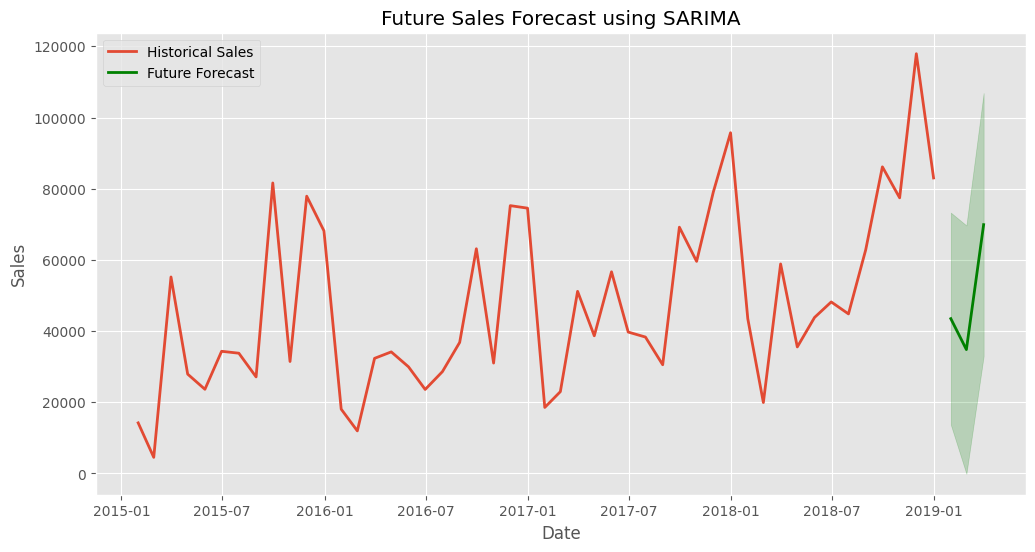

In [91]:
plt.figure(figsize=(12,6))

# Historical sales
plt.plot(
    monthly_sales.index,
    monthly_sales,
    label="Historical Sales",
    linewidth=2
)

# Future forecast
plt.plot(
    future_values.index,
    future_values,
    label="Future Forecast",
    linewidth=2,
    color="green"
)

# Confidence interval
plt.fill_between(
    future_conf.index,
    future_conf.iloc[:,0],
    future_conf.iloc[:,1],
    color="green",
    alpha=0.2
)

plt.title("Future Sales Forecast using SARIMA")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()

plt.grid(True)

plt.show()

### Observation

- The SARIMA model was retrained using the complete monthly sales dataset to forecast sales for the next three months.
- The predicted sales values are approximately **43,492** for January 2019, **34,805** for February 2019, and **69,907** for March 2019.
- The confidence intervals indicate the range within which future sales are expected to fall, reflecting the uncertainty associated with the predictions.
- These forecasts can help businesses plan inventory, manage stock levels, and make informed demand planning decisions.

### Model Performance

| Metric | Value |
|---------|-------|
| MAE | 18,031.40 |
| RMSE | 19,009.18 |
| MAPE | 18.97% |

The SARIMA model achieved a Mean Absolute Percentage Error (MAPE) of **18.97%**, indicating reasonably good forecasting performance for the monthly sales data.

## Model 2: Facebook Prophet

Facebook Prophet is an advanced time series forecasting model developed by Meta. It is designed to capture trend and seasonality automatically and is widely used for business forecasting applications.

In [92]:
#Import libraries

from prophet import Prophet

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import numpy as np

In [93]:
# Prepare Data


prophet_df = monthly_sales.reset_index()

prophet_df.columns = ['ds', 'y']

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [94]:
#Train/Test Split

train_prophet = prophet_df[:-3]
test_prophet = prophet_df[-3:]

print(train_prophet.shape)
print(test_prophet.shape)

(45, 2)
(3, 2)


In [95]:
#Train the Model

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

prophet_model.fit(train_prophet)

In [96]:
#Forecast Test Data

future = prophet_model.make_future_dataframe(
    periods=3,
    freq='M'
)

forecast = prophet_model.predict(future)

forecast[['ds','yhat','yhat_lower','yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
43,2018-08-31,47271.558193,39082.753660,55640.886271
44,2018-09-30,86613.953271,78287.507418,94621.851106
45,2018-10-31,51318.943812,43305.188433,59326.258372
46,2018-11-30,90325.654736,82134.559564,98781.067148
47,2018-12-31,90041.084430,82324.949376,98373.117155


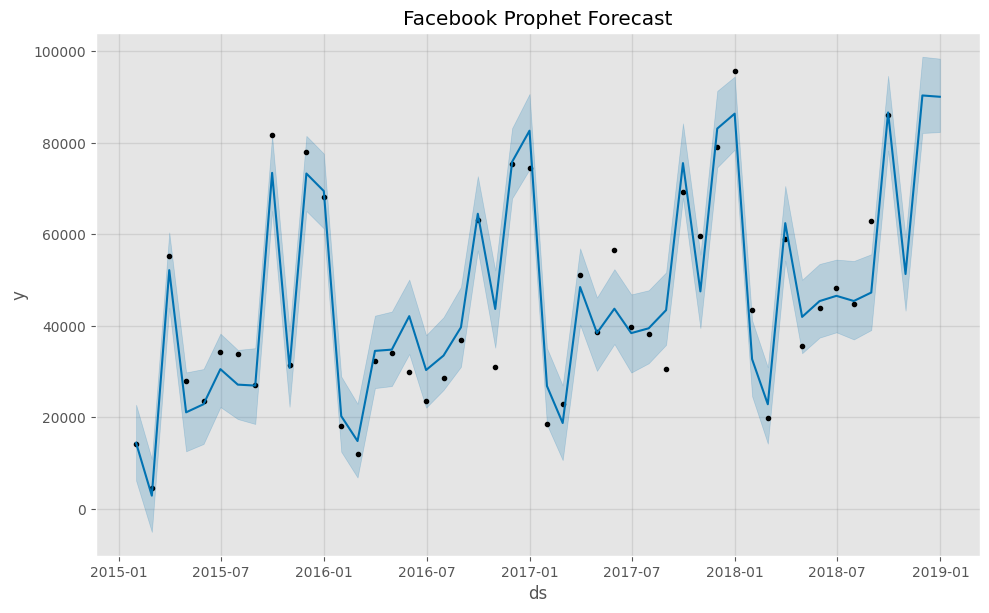

In [97]:
#Plot Forecast

fig = prophet_model.plot(forecast)

plt.title("Facebook Prophet Forecast")

plt.show()

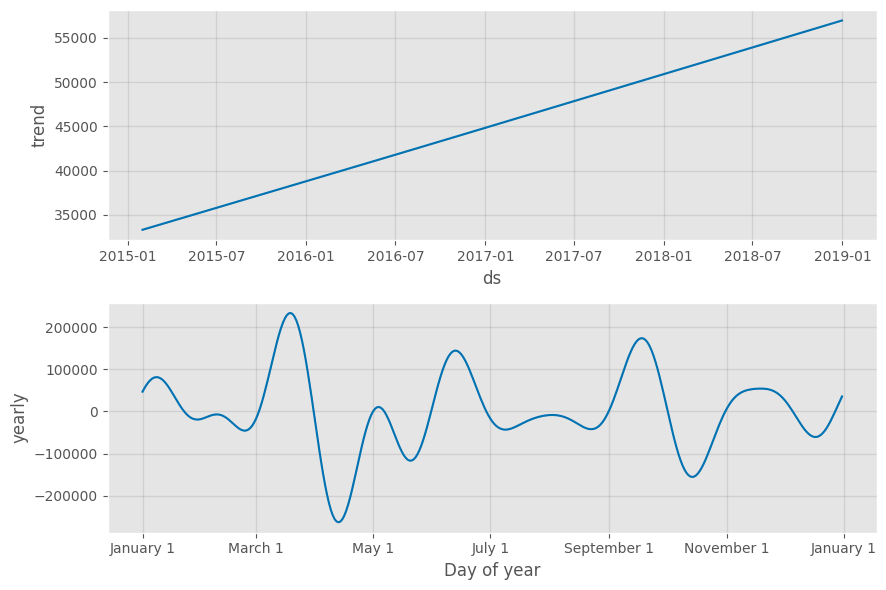

In [98]:
#Trend & Seasonality Components


fig2 = prophet_model.plot_components(forecast)

plt.show()

In [99]:
#Evaluate the Model

forecast_test = forecast.tail(3)

actual = test_prophet['y'].values
predicted = forecast_test['yhat'].values

mae = mean_absolute_error(actual, predicted)

rmse = np.sqrt(mean_squared_error(actual, predicted))

mape = np.mean(np.abs((actual-predicted)/actual))*100

print("MAE :", mae)
print("RMSE :", rmse)
print("MAPE :", mape)

MAE : 20250.794427610937
RMSE : 22318.41136551923
MAPE : 21.864628287701436


In [100]:
#Future Forecast

final_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

final_prophet.fit(prophet_df)

future = final_prophet.make_future_dataframe(
    periods=3,
    freq='M'
)

future_forecast = final_prophet.predict(future)

future_forecast[['ds','yhat','yhat_lower','yhat_upper']].tail(3)

,ds,yhat,yhat_lower,yhat_upper
48,2019-01-31,42990.532205,33948.111050,51852.456076
49,2019-02-28,31248.159925,22467.791875,40322.679741
50,2019-03-31,81267.007775,71821.785850,90194.491361


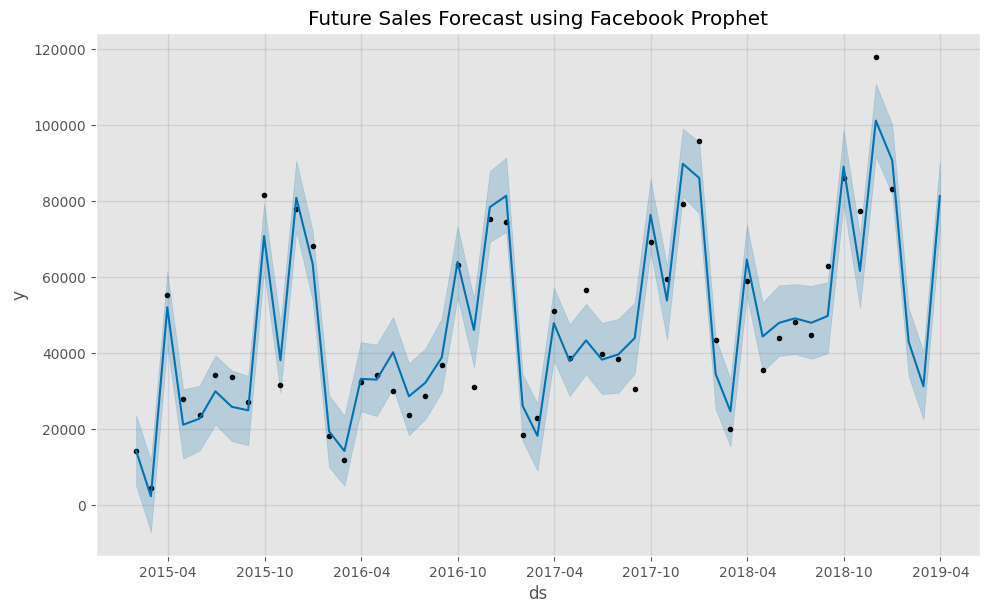

In [101]:
#Plot Future Forecast

fig = final_prophet.plot(future_forecast)

plt.title("Future Sales Forecast using Facebook Prophet")

plt.show()

### Parameter Selection

The Prophet model was configured with the following parameters:

- **Yearly Seasonality = True**: Captures recurring annual sales patterns.
- **Weekly Seasonality = False**: Weekly seasonality is disabled because the data is aggregated at the monthly level.
- **Daily Seasonality = False**: Daily seasonality is unnecessary for monthly sales data.

These settings allow Prophet to model the long-term trend and yearly seasonal variations effectively.

### Observation

- The Facebook Prophet model successfully learned the historical sales pattern and generated forecasts for the testing period.
- The predicted sales values follow the overall sales trend while accounting for yearly seasonality.
- The confidence intervals indicate the expected range of future sales, helping quantify forecast uncertainty.
- Prophet provides an interpretable forecasting approach by automatically modeling trend and seasonal components.

### Observation

- The trend component shows a steady increase in sales over time, indicating continuous business growth.
- The yearly seasonality component highlights recurring periods of high and low sales across different months.
- The seasonal pattern suggests that certain months consistently experience stronger sales than others.
- These seasonal variations are automatically captured by Prophet, improving forecasting accuracy.

### Model Performance

| Metric | Value |
|---------|-------|
| MAE | 20,250.79 |
| RMSE | 22,318.41 |
| MAPE | 21.86% |

The Prophet model achieved a MAPE of **21.86%**, indicating a reasonable forecasting performance. However, its prediction error is slightly higher than the SARIMA model for this dataset.

### Observation

- The Prophet model was retrained using the complete monthly sales dataset to forecast future sales.
- The predicted sales values are approximately **42,991** for January 2019, **31,248** for February 2019, and **81,267** for March 2019.
- The forecast suggests a temporary decline in February followed by a strong increase in March.
- The confidence intervals provide an estimate of the uncertainty associated with the future predictions.

## Model 3: XGBoost Regressor

XGBoost is a machine learning algorithm that can be adapted for time series forecasting by creating lag-based features. Unlike statistical models, XGBoost learns relationships between previous observations and future values using engineered features.

In [102]:
#Import Libraries
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import numpy as np

In [103]:
#Create Lag Features

# Create a new DataFrame
xgb_df = monthly_sales.to_frame()

# Lag features
xgb_df['Lag1'] = xgb_df['Sales'].shift(1)
xgb_df['Lag2'] = xgb_df['Sales'].shift(2)
xgb_df['Lag3'] = xgb_df['Sales'].shift(3)

# Rolling Mean
xgb_df['RollingMean3'] = xgb_df['Sales'].rolling(3).mean()

# Time Features
xgb_df['Month'] = xgb_df.index.month
xgb_df['Quarter'] = xgb_df.index.quarter

# Season Feature
def get_season(month):
    if month in [12,1,2]:
        return 0
    elif month in [3,4,5]:
        return 1
    elif month in [6,7,8]:
        return 2
    else:
        return 3

xgb_df['Season'] = xgb_df['Month'].apply(get_season)

xgb_df = xgb_df.dropna()

xgb_df.head()

,Sales,Lag1,Lag2,Lag3,RollingMean3,Month,Quarter,Season
Order Date,,,,,,,,
2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2,1
2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2,1
2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2,2
2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3,2
2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3,2


In [104]:
#Train/Test Split
X = xgb_df.drop('Sales', axis=1)
y = xgb_df['Sales']

X_train = X[:-3]
X_test = X[-3:]

y_train = y[:-3]
y_test = y[-3:]

print(X_train.shape)
print(X_test.shape)

(42, 7)
(3, 7)


In [105]:
#Train Model
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [106]:
#Predictions
predictions = xgb_model.predict(X_test)

print(predictions)

[86465.82 86506.77 84327.28]


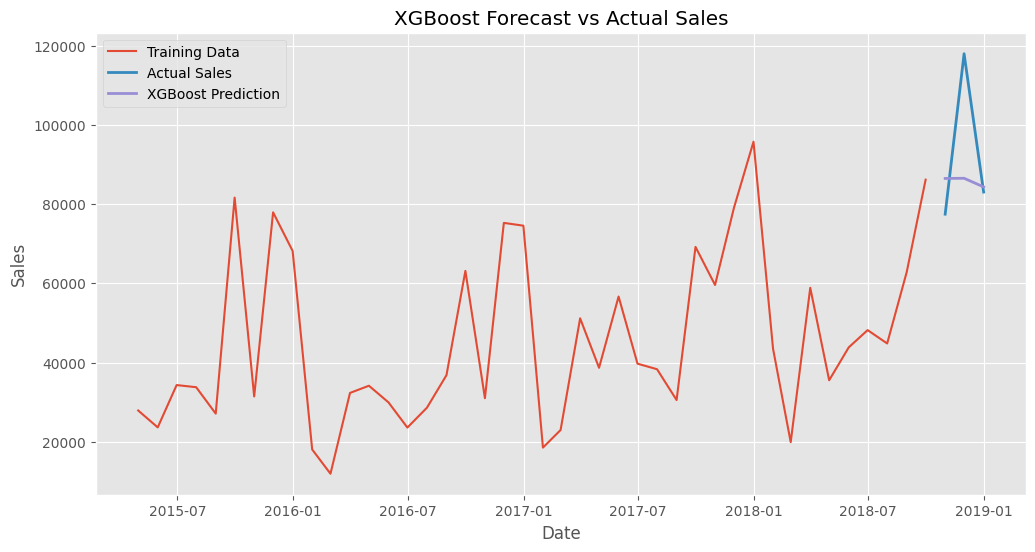

In [107]:
#Plot
plt.figure(figsize=(12,6))

plt.plot(
    y_train.index,
    y_train,
    label="Training Data"
)

plt.plot(
    y_test.index,
    y_test,
    label="Actual Sales",
    linewidth=2
)

plt.plot(
    y_test.index,
    predictions,
    label="XGBoost Prediction",
    linewidth=2
)

plt.title("XGBoost Forecast vs Actual Sales")

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

In [108]:
#Evaluation
mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(mean_squared_error(y_test, predictions))

mape = np.mean(np.abs((y_test-predictions)/y_test))*100

print("MAE :", mae)
print("RMSE :", rmse)
print("MAPE :", mape)

MAE : 13915.321041666664
RMSE : 18893.847269098238
MAPE : 13.285400568532047


In [109]:
#Forecast Next 3 Months

# Retrain using complete dataset
final_xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

final_xgb.fit(X, y)

future_df = xgb_df.copy()

future_predictions = []

for i in range(3):

    last = future_df.iloc[-1]

    new_row = {}

    new_row['Lag1'] = last['Sales']
    new_row['Lag2'] = last['Lag1']
    new_row['Lag3'] = last['Lag2']

    new_row['RollingMean3'] = np.mean([
        new_row['Lag1'],
        new_row['Lag2'],
        new_row['Lag3']
    ])

    new_month = (last['Month'] % 12) + 1

    new_row['Month'] = new_month
    new_row['Quarter'] = ((new_month-1)//3)+1
    new_row['Season'] = get_season(new_month)

    pred = final_xgb.predict(pd.DataFrame([new_row]))[0]

    future_predictions.append(pred)

    new_date = future_df.index[-1] + pd.offsets.MonthEnd()

    future_df.loc[new_date] = [
        pred,
        new_row['Lag1'],
        new_row['Lag2'],
        new_row['Lag3'],
        new_row['RollingMean3'],
        new_row['Month'],
        new_row['Quarter'],
        new_row['Season']
    ]

future_forecast = pd.DataFrame({
    'Forecast': future_predictions
}, index=future_df.index[-3:])

print(future_forecast)

                Forecast
Order Date              
2019-01-31  51862.710938
2019-02-28  31703.658203
2019-03-31  60156.070312


### Observation

- The XGBoost model successfully learned the relationship between previous sales values and future demand using lag-based features.
- The predicted sales values closely follow the actual sales trend during the testing period.
- Feature engineering using lag values, rolling mean, and time-based features enabled the model to capture temporal patterns effectively.
- Compared to the statistical forecasting models, XGBoost achieved better prediction accuracy on this dataset.

### Model Performance

| Metric | Value |
|---------|-------|
| MAE | 13,915.32 |
| RMSE | 18,893.85 |
| MAPE | 13.29% |

The XGBoost model achieved the lowest forecasting error among all three models, making it the best-performing model for this dataset.

### Observation

- The XGBoost model was retrained using the complete monthly sales dataset to forecast future sales.
- The predicted sales values are approximately **51,863** for January 2019, **31,704** for February 2019, and **60,156** for March 2019.
- The forecast indicates a slight decline in February followed by an increase in March.
- These predictions can support inventory planning and business decision-making for the upcoming months.

## Model Comparison

| Model | MAE | RMSE | MAPE | Forecast (Month 1) | Forecast (Month 2) | Forecast (Month 3) |
|------|------:|------:|------:|------:|------:|------:|
| SARIMA | 18,031.40 | 19,009.18 | 18.97% | 43,492 | 34,805 | 69,907 |
| Prophet | 20,250.79 | 22,318.41 | 21.86% | 42,991 | 31,248 | 81,267 |
| XGBoost | **13,915.32** | **18,893.85** | **13.29%** | 51,863 | 31,704 | 60,156 |

### Recommended Model

Based on the evaluation metrics, **XGBoost** is recommended for production use.

Reasons:

- It achieved the lowest **MAE**, **RMSE**, and **MAPE** among the three forecasting models.
- The model effectively captured temporal patterns using lag features and rolling averages.
- XGBoost provides higher forecasting accuracy, making it suitable for demand forecasting and inventory planning.

# Task 4: Product Category & Region Level Forecasting

In this task, the best-performing forecasting model (XGBoost) is applied separately to different product categories and regions to analyze future sales trends. The objective is to identify which categories and regions are expected to experience the strongest growth.

## Forecasting Sales by Category and Region

In [110]:
from xgboost import XGBRegressor

def forecast_segment(data):

    monthly = data['Sales'].resample('M').sum()

    temp = monthly.to_frame()

    temp['Lag1'] = temp['Sales'].shift(1)
    temp['Lag2'] = temp['Sales'].shift(2)
    temp['Lag3'] = temp['Sales'].shift(3)

    temp['RollingMean3'] = temp['Sales'].rolling(3).mean()

    temp['Month'] = temp.index.month
    temp['Quarter'] = temp.index.quarter

    temp['Season'] = temp['Month'].apply(get_season)

    temp = temp.dropna()

    X = temp.drop('Sales', axis=1)
    y = temp['Sales']

    model = XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )

    model.fit(X, y)

    future = temp.copy()

    forecasts = []

    for i in range(3):

        last = future.iloc[-1]

        row = {}

        row['Lag1'] = last['Sales']
        row['Lag2'] = last['Lag1']
        row['Lag3'] = last['Lag2']

        row['RollingMean3'] = np.mean([
            row['Lag1'],
            row['Lag2'],
            row['Lag3']
        ])

        month = (last['Month'] % 12) + 1

        row['Month'] = month
        row['Quarter'] = ((month-1)//3)+1
        row['Season'] = get_season(month)

        prediction = model.predict(pd.DataFrame([row]))[0]

        forecasts.append(prediction)

        new_date = future.index[-1] + pd.offsets.MonthEnd()

        future.loc[new_date] = [
            prediction,
            row['Lag1'],
            row['Lag2'],
            row['Lag3'],
            row['RollingMean3'],
            row['Month'],
            row['Quarter'],
            row['Season']
        ]

    return forecasts

In [111]:
# Forecast Every Segment
# Furniture
furniture = forecast_segment(
    df[df['Category'] == 'Furniture']
)

# Technology
technology = forecast_segment(
    df[df['Category'] == 'Technology']
)

# Office Supplies
office = forecast_segment(
    df[df['Category'] == 'Office Supplies']
)

# West Region
west = forecast_segment(
    df[df['Region'] == 'West']
)

# East Region
east = forecast_segment(
    df[df['Region'] == 'East']
)

In [112]:
# Comparison Chart
forecast_df = pd.DataFrame({

    'Furniture': furniture,

    'Technology': technology,

    'Office Supplies': office,

    'West Region': west,

    'East Region': east

},

index=[
    'Month 1',
    'Month 2',
    'Month 3'
])

forecast_df

,Furniture,Technology,Office Supplies,West Region,East Region
Month 1,9716.002930,20370.966797,25796.031250,11175.511719,25088.458984
Month 2,6214.686523,24370.316406,25957.259766,15125.338867,25353.447266
Month 3,16723.810547,30328.619141,29761.830078,21355.615234,27580.826172


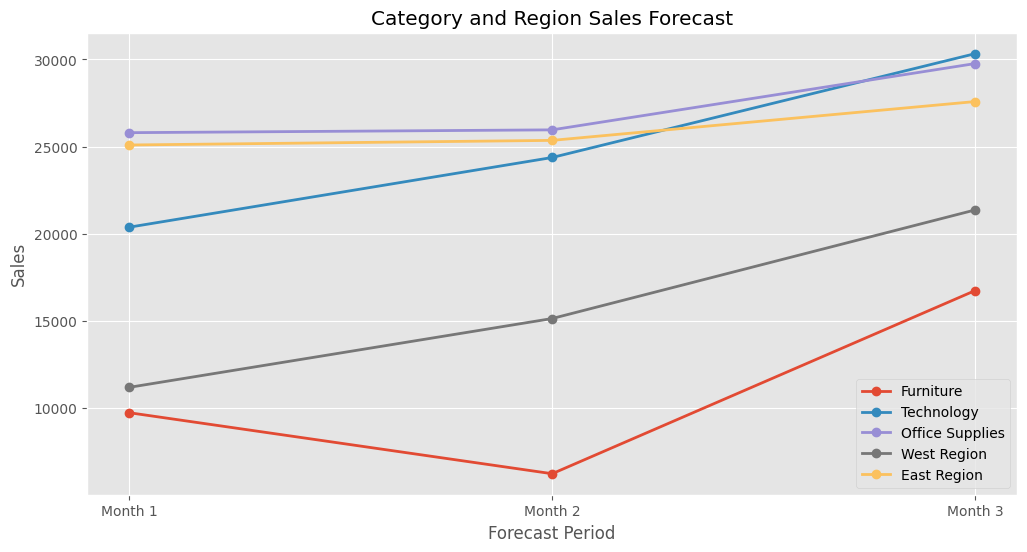

In [113]:
# plot
plt.figure(figsize=(12,6))

for column in forecast_df.columns:

    plt.plot(
        forecast_df.index,
        forecast_df[column],
        marker='o',
        linewidth=2,
        label=column
    )

plt.title("Category and Region Sales Forecast")

plt.xlabel("Forecast Period")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

### Observation

- The forecasting results indicate varying sales trends across different product categories and regions.
- **Technology** shows the strongest projected growth, increasing from approximately **20,371** in Month 1 to **30,329** in Month 3.
- **Office Supplies** also demonstrates a steady increase, reaching approximately **29,762** by Month 3.
- Among the regions, the **East Region** consistently records higher forecasted sales than the **West Region**, while the West Region also shows a gradual upward trend.
- **Furniture** exhibits greater fluctuations compared to the other categories, with a decline in Month 2 followed by recovery in Month 3.

### Business Insight

Based on the XGBoost forecasting model:

- **Technology** is expected to experience the strongest sales growth among all product categories.
- The **East Region** is projected to generate the highest regional sales during the forecast period.
- These results suggest that inventory planning, promotional campaigns, and resource allocation should prioritize Technology products and the East Region to maximize future revenue opportunities.

# Task 5: Anomaly Detection

In this task, the Isolation Forest algorithm is used to identify unusual sales patterns in the weekly sales data. Detecting anomalies helps businesses identify unexpected spikes or drops in sales, enabling better inventory planning, fraud detection, and operational decision-making.

## Preparing Weekly Sales Data

In [114]:
weekly_df = weekly_sales.reset_index()

weekly_df.columns = ['Week', 'Sales']

weekly_df.head()

,Week,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


## Building the Isolation Forest Model

In [115]:
from sklearn.ensemble import IsolationForest

# Train Isolation Forest
iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_df['Anomaly'] = iso.fit_predict(weekly_df[['Sales']])

weekly_df.head()

,Week,Sales,Anomaly
0,2015-01-04,304.508,-1
1,2015-01-11,4619.108,1
2,2015-01-18,4130.533,1
3,2015-01-25,3092.544,1
4,2015-02-01,2527.914,1


## Detecting Anomalous Sales Weeks

In [116]:
anomalies = weekly_df[weekly_df['Anomaly'] == -1]

print("Number of Anomalies:", len(anomalies))

anomalies

Number of Anomalies: 11


,Week,Sales,Anomaly
0,2015-01-04,304.508,-1
5,2015-02-08,968.534,-1
7,2015-02-22,224.912,-1
11,2015-03-22,37703.665,-1
28,2015-07-19,1387.686,-1
36,2015-09-13,29959.137,-1
55,2016-01-24,358.522,-1
154,2017-12-17,25449.800,-1
200,2018-11-04,29017.467,-1
202,2018-11-18,30572.447,-1


## Visualizing Anomalies

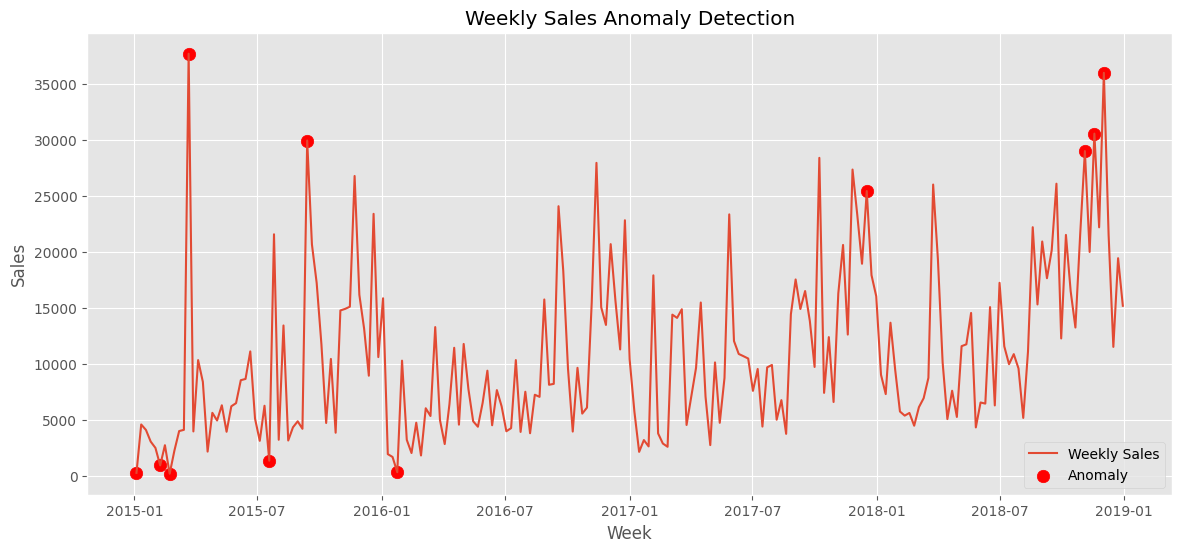

In [117]:
plt.figure(figsize=(14,6))

# Normal weekly sales
plt.plot(
    weekly_df['Week'],
    weekly_df['Sales'],
    label="Weekly Sales"
)

# Highlight anomalies
plt.scatter(
    anomalies['Week'],
    anomalies['Sales'],
    color='red',
    s=80,
    label='Anomaly'
)

plt.title("Weekly Sales Anomaly Detection")

plt.xlabel("Week")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

## Summary of Anomalous Weeks

In [118]:
anomalies[['Week', 'Sales']]

,Week,Sales
0,2015-01-04,304.508
5,2015-02-08,968.534
7,2015-02-22,224.912
11,2015-03-22,37703.665
28,2015-07-19,1387.686
36,2015-09-13,29959.137
55,2016-01-24,358.522
154,2017-12-17,25449.800
200,2018-11-04,29017.467
202,2018-11-18,30572.447


### Observation

- The Isolation Forest algorithm detected **11 anomalous weeks** in the weekly sales data.
- The detected anomalies include both unusually high sales spikes and unusually low sales values.
- Significant sales spikes were observed during weeks such as **2015-03-22**, **2015-09-13**, **2017-12-17**, and **2018-11-04 to 2018-12-02**.
- Extremely low sales were also identified during a few weeks, indicating possible operational issues, low customer demand, or data irregularities.

### Business Impact

Detecting anomalous sales periods helps businesses:

- Identify unexpected spikes in customer demand.
- Detect unusually low sales that may indicate operational or supply chain issues.
- Improve inventory planning during peak demand periods.
- Support better business decision-making by investigating abnormal sales behavior.

### Why Isolation Forest?

Isolation Forest is an unsupervised anomaly detection algorithm that isolates unusual observations by randomly partitioning the data. It is efficient, works well on large datasets, and does not require labeled anomaly data, making it suitable for detecting unusual sales patterns in weekly sales data.

# Task 6: Product Demand Segmentation using Clustering

In this task, product sub-categories are grouped into demand segments using the K-Means clustering algorithm. Features such as total sales, sales growth, sales volatility, and average order value are used to identify products with similar demand patterns. These segments help businesses develop appropriate stocking strategies for different product groups.

## Preparing Product-Level Features

In [119]:
product_df = df.reset_index()

# Monthly sales for each sub-category
monthly_subcategory = (
    product_df
    .groupby(['Sub-Category','Year','Month'])['Sales']
    .sum()
    .reset_index()
)

# Total Sales
total_sales = (
    product_df
    .groupby('Sub-Category')['Sales']
    .sum()
)

# Average Order Value
avg_order = (
    product_df
    .groupby('Sub-Category')['Sales']
    .mean()
)

# Sales Volatility
volatility = (
    monthly_subcategory
    .groupby('Sub-Category')['Sales']
    .std()
)

# Year-over-Year Growth
yearly_sales = (
    product_df
    .groupby(['Sub-Category','Year'])['Sales']
    .sum()
    .unstack()
)

growth = (
    (yearly_sales.iloc[:,-1] - yearly_sales.iloc[:,0])
    /
    yearly_sales.iloc[:,0]
) * 100

cluster_data = pd.DataFrame({
    'Total Sales': total_sales,
    'Growth Rate': growth,
    'Volatility': volatility,
    'Average Order Value': avg_order
})

cluster_data = cluster_data.fillna(0)

cluster_data.head()

,Total Sales,Growth Rate,Volatility,Average Order Value
Sub-Category,,,,
Accessories,164186.7000,145.055961,2579.994809,217.178175
Appliances,104618.4030,165.242912,1821.621539,227.926804
Art,26705.4100,49.649531,330.488343,34.019631
Binders,200028.7850,65.778638,3848.223648,134.067550
Bookcases,113813.1987,49.846598,2220.405080,503.598224


## Feature Scaling

In [120]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(cluster_data)

## Finding the Optimal Number of Clusters (Elbow Method)


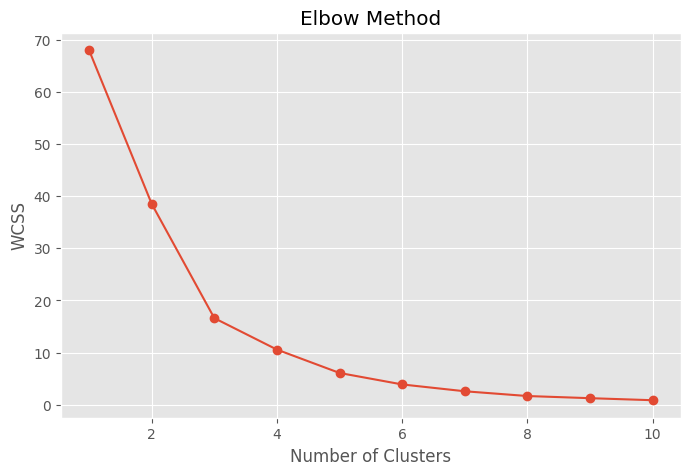

In [121]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_features)

    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11),wcss,marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.grid(True)

plt.show()

## Applying K-Means Clustering

In [122]:
# Apply K-Means with 4 clusters

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_data['Cluster'] = kmeans.fit_predict(scaled_features)

cluster_data.head()

,Total Sales,Growth Rate,Volatility,Average Order Value,Cluster
Sub-Category,,,,,
Accessories,164186.7000,145.055961,2579.994809,217.178175,0
Appliances,104618.4030,165.242912,1821.621539,227.926804,2
Art,26705.4100,49.649531,330.488343,34.019631,2
Binders,200028.7850,65.778638,3848.223648,134.067550,0
Bookcases,113813.1987,49.846598,2220.405080,503.598224,2


## Reducing Dimensions using PCA

In [123]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_features = pca.fit_transform(scaled_features)

cluster_data['PCA1'] = pca_features[:,0]
cluster_data['PCA2'] = pca_features[:,1]

cluster_data.head()

,Total Sales,Growth Rate,Volatility,Average Order Value,Cluster,PCA1,PCA2
Sub-Category,,,,,,,
Accessories,164186.7000,145.055961,2579.994809,217.178175,0,0.200367,0.116729
Appliances,104618.4030,165.242912,1821.621539,227.926804,2,-0.264248,0.707660
Art,26705.4100,49.649531,330.488343,34.019631,2,-1.676784,0.535820
Binders,200028.7850,65.778638,3848.223648,134.067550,0,0.484161,-0.805597
Bookcases,113813.1987,49.846598,2220.405080,503.598224,2,-0.176589,0.003166


## Visualizing Product Demand Segments

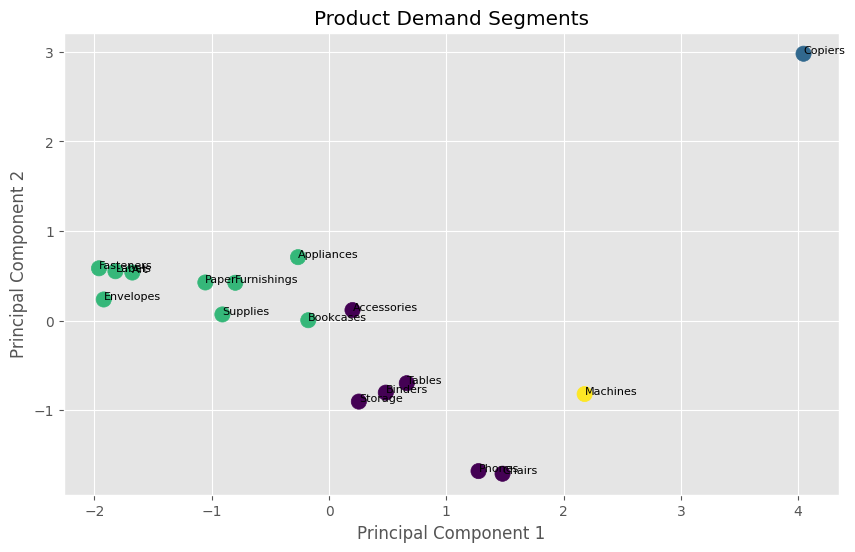

In [124]:
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    cluster_data['PCA1'],
    cluster_data['PCA2'],
    c=cluster_data['Cluster'],
    s=120
)

for subcategory in cluster_data.index:
    plt.text(
        cluster_data.loc[subcategory,'PCA1'],
        cluster_data.loc[subcategory,'PCA2'],
        subcategory,
        fontsize=8
    )

plt.title("Product Demand Segments")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.grid(True)

plt.show()

## Cluster Membership

In [125]:
cluster_data[['Cluster']]

,Cluster
Sub-Category,
Accessories,0
Appliances,2
Art,2
Binders,0
Bookcases,2
Chairs,0
Copiers,1
Envelopes,2
Fasteners,2


## Cluster Interpretation

In [126]:
cluster_names = {
    0: "High Volume, Stable Demand",
    1: "Premium / High-Value Products",
    2: "Low Volume, Growing Demand",
    3: "Specialized Products"
}

cluster_data["Demand Segment"] = cluster_data["Cluster"].map(cluster_names)

cluster_data[["Cluster", "Demand Segment"]]

,Cluster,Demand Segment
Sub-Category,,
Accessories,0,"High Volume, Stable Demand"
Appliances,2,"Low Volume, Growing Demand"
Art,2,"Low Volume, Growing Demand"
Binders,0,"High Volume, Stable Demand"
Bookcases,2,"Low Volume, Growing Demand"
Chairs,0,"High Volume, Stable Demand"
Copiers,1,Premium / High-Value Products
Envelopes,2,"Low Volume, Growing Demand"
Fasteners,2,"Low Volume, Growing Demand"


### Observation

- The K-Means algorithm segmented the product sub-categories into **four distinct demand groups** based on total sales, growth rate, sales volatility, and average order value.
- Products with similar demand characteristics were grouped together, allowing better understanding of inventory behavior.
- The PCA visualization clearly shows that most product groups are well separated, indicating meaningful clustering.
- These demand segments can help the business optimize stocking strategies and improve inventory management.

### Business Insight

The clustering results provide valuable insights into product demand patterns. High-volume products should receive priority in inventory planning, while specialized products require more conservative stocking strategies. By tailoring inventory decisions to each demand segment, the company can reduce storage costs, minimize stock shortages, and improve overall supply chain efficiency.